In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import pandas as pd

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"{name:25} rows={df.shape[0]:>8,} columns={df.shape[1]:>3}")

customers                 rows=  99,441 columns=  5
orders                    rows=  99,441 columns=  8
order_items               rows= 112,650 columns=  7
payments                  rows= 103,886 columns=  5
reviews                   rows=  99,224 columns=  7
products                  rows=  32,951 columns=  9
sellers                   rows=   3,095 columns=  4
geolocation               rows=1,000,163 columns=  5
category_translation      rows=      71 columns=  2


In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [5]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [9]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [10]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [11]:
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [12]:
orders["order_purchase_timestamp"].min(), orders["order_purchase_timestamp"].max()

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

In [13]:
total_orders = orders["order_id"].nunique()

delivered_orders = (
    orders[orders["order_status"] == "delivered"]["order_id"].nunique()
)

cancelled_orders = (
    orders[orders["order_status"] == "canceled"]["order_id"].nunique()
)

cancellation_rate = cancelled_orders / total_orders * 100

print("Total Orders:", total_orders)
print("Delivered Orders:", delivered_orders)
print("Cancelled Orders:", cancelled_orders)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Total Orders: 99441
Delivered Orders: 96478
Cancelled Orders: 625
Cancellation Rate: 0.63 %


In [14]:
total_revenue = order_items["price"].sum()

print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 13591643.7


In [15]:
aov = total_revenue / orders["order_id"].nunique()

print("Average Order Value:", round(aov, 2))

Average Order Value: 136.68


In [16]:
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [18]:
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")

In [19]:
monthly_revenue = (
    order_items
    .merge(
        orders[["order_id", "month"]],
        on="order_id",
        how="left"
    )
    .groupby("month")["price"]
    .sum()
    .reset_index()
)

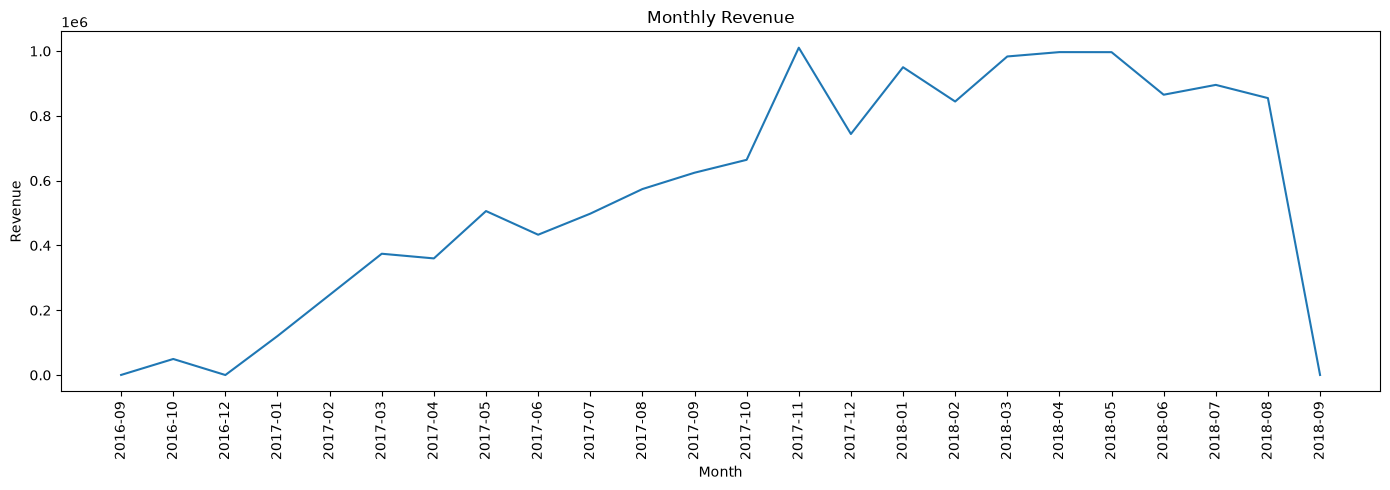

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_revenue["month"].astype(str),
    monthly_revenue["price"]
)

plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.tight_layout()
plt.show()

In [21]:
monthly_revenue["growth_%"] = (
    monthly_revenue["price"].pct_change() * 100
).round(2)

monthly_revenue

,month,price,growth_%
0,2016-09,267.36,NaN
1,2016-10,49507.66,18417.23
2,2016-12,10.90,-99.98
3,2017-01,120312.87,1103687.80
4,2017-02,247303.02,105.55
5,2017-03,374344.30,51.37
6,2017-04,359927.23,-3.85
7,2017-05,506071.14,40.60
8,2017-06,433038.60,-14.43
9,2017-07,498031.48,15.01


In [22]:
best_month = monthly_revenue.loc[
    monthly_revenue["price"].idxmax()
]

worst_month = monthly_revenue.loc[
    monthly_revenue["price"].idxmin()
]

print("Best month:")
print(best_month)

print("\nWorst month:")
print(worst_month)

Best month:
month          2017-11
price       1010271.37
growth_%          52.1
Name: 13, dtype: object

Worst month:
month       2016-12
price          10.9
growth_%     -99.98
Name: 2, dtype: object


In [23]:
customer_orders = (
    orders.groupby("customer_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

customer_orders.head()

,customer_id,order_count
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


In [24]:
customer_orders["order_count"].value_counts().sort_index()

order_count
1    99441
Name: count, dtype: int64

In [25]:
total_customers = customer_orders["customer_id"].nunique()

repeat_customers = (
    customer_orders[customer_orders["order_count"] > 1]
    ["customer_id"]
    .nunique()
)

repeat_rate = repeat_customers / total_customers * 100

print("Total Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", round(repeat_rate, 2), "%")

Total Customers: 99441
Repeat Customers: 0
Repeat Customer Rate: 0.0 %


In [26]:
customer_revenue = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_id")["price"]
    .sum()
    .reset_index(name="revenue")
)

customer_revenue.head()

,customer_id,revenue
0,00012a2ce6f8dcda20d059ce98491703,89.80
1,000161a058600d5901f007fab4c27140,54.90
2,0001fd6190edaaf884bcaf3d49edf079,179.99
3,0002414f95344307404f0ace7a26f1d5,149.90
4,000379cdec625522490c315e70c7a9fb,93.00


In [27]:
customer_analysis = customer_orders.merge(
    customer_revenue,
    on="customer_id",
    how="left"
)

customer_analysis.head()

,customer_id,order_count,revenue
0,00012a2ce6f8dcda20d059ce98491703,1,89.80
1,000161a058600d5901f007fab4c27140,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99
3,0002414f95344307404f0ace7a26f1d5,1,149.90
4,000379cdec625522490c315e70c7a9fb,1,93.00


In [28]:
customer_analysis.sort_values(
    "revenue",
    ascending=False
).head(10)

,customer_id,order_count,revenue
8546,1617b1357756262bfa56ab541c47bc16,1,13440.0
91985,ec5b2ba62e574342386871631fafd3fc,1,7160.0
77522,c6e2731c5b391845f6800c97401a43a9,1,6735.0
95124,f48d464a0baaea338cb25f816991ab1f,1,6729.0
24771,3fd6777bbce08a352fddd04e4a7cc8f6,1,6499.0
2065,05455dfa7cd02f13d132aa7a6a9729c6,1,5934.6
86908,df55c14d1476a9a3467f131269c2477f,1,4799.0
14282,24bbf5fd2f2e1b359ee7de94defc4a15,1,4690.0
87397,e0a2412720e9ea4f26c1ac985f6a7358,1,4599.9
23932,3d979689f636322c62418b6346b1c6d2,1,4590.0


In [29]:
customer_analysis["revenue"].describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: revenue, dtype: float64

In [30]:
# Map each order to the actual unique customer
order_customer = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# Orders per unique customer
customer_orders = (
    order_customer
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

# Repeat customer analysis
total_customers = customer_orders["customer_unique_id"].nunique()

repeat_customers = (
    customer_orders[customer_orders["order_count"] > 1]
    ["customer_unique_id"]
    .nunique()
)

repeat_rate = repeat_customers / total_customers * 100

print("Total Unique Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", round(repeat_rate, 2), "%")

Total Unique Customers: 96096
Repeat Customers: 2997
Repeat Customer Rate: 3.12 %


In [31]:
customer_revenue = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_unique_id")["price"]
    .sum()
    .reset_index(name="revenue")
)

customer_analysis = customer_orders.merge(
    customer_revenue,
    on="customer_unique_id",
    how="left"
)

customer_analysis.sort_values(
    "revenue",
    ascending=False
).head(10)

,customer_unique_id,order_count,revenue
3826,0a0a92112bd4c708ca5fde585afaa872,1,13440.0
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7388.0
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6735.0
26205,459bef486812aa25204be022145caa62,1,6729.0
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.0
24121,4007669dec559734d6f53e029e360987,1,5934.6
89688,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.0
35070,5d0a2980b292d049061542014e8960bf,1,4599.9
27441,48e1ac109decbb87765a3eade6854098,1,4590.0


In [32]:
# Merge orders with unique customer ID
rfm_data = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# Add revenue to each order
order_revenue = (
    order_items
    .groupby("order_id")["price"]
    .sum()
    .reset_index(name="revenue")
)

rfm_data = rfm_data.merge(
    order_revenue,
    on="order_id",
    how="left"
)

# Use the latest purchase date as the analysis reference
analysis_date = rfm_data["order_purchase_timestamp"].max()

rfm = (
    rfm_data
    .groupby("customer_unique_id")
    .agg(
        Recency=("order_purchase_timestamp",
                 lambda x: (analysis_date - x.max()).days),
        Frequency=("order_id", "nunique"),
        Monetary=("revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90
2,0000f46a3911fa3c0805444483337064,585,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,336,1,180.00


In [33]:
rfm.describe()

,Recency,Frequency,Monetary
count,96096.000000,96096.000000,96096.000000
mean,287.735691,1.034809,141.438184
std,153.414676,0.214384,217.215904
min,0.000000,1.000000,0.000000
25%,163.000000,1.000000,45.990000
50%,268.000000,1.000000,89.000000
75%,397.000000,1.000000,154.000000
max,772.000000,17.000000,13440.000000


In [34]:
# Create RFM scores

rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Convert scores to integers
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

# Overall RFM score
rfm["RFM_score"] = (
    rfm["R_score"] +
    rfm["F_score"] +
    rfm["M_score"]
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90,4,1,4,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90,4,1,1,6
2,0000f46a3911fa3c0805444483337064,585,1,69.00,1,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,25.99,2,1,1,4
4,0004aac84e0df4da2b147fca70cf8255,336,1,180.00,2,1,5,8


In [35]:
rfm[[
    "Recency",
    "Frequency",
    "Monetary",
    "R_score",
    "F_score",
    "M_score",
    "RFM_score"
]].describe()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
count,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000
mean,287.735691,1.034809,141.438184,3.004027,2.999979,2.999979,9.003986
std,153.414676,0.214384,217.215904,1.415035,1.414228,1.414228,2.500740
min,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,3.000000
25%,163.000000,1.000000,45.990000,2.000000,2.000000,2.000000,7.000000
50%,268.000000,1.000000,89.000000,3.000000,3.000000,3.000000,9.000000
75%,397.000000,1.000000,154.000000,4.000000,4.000000,4.000000,11.000000
max,772.000000,17.000000,13440.000000,5.000000,5.000000,5.000000,15.000000


In [36]:
rfm["RFM_score"].value_counts().sort_index()

RFM_score
3       846
4      2407
5      4871
6      7789
7     11392
8     13617
9     14444
10    13543
11    11158
12     7740
13     4798
14     2471
15     1020
Name: count, dtype: int64

In [37]:
def segment_customer(score):
    if score >= 13:
        return "Champions"
    elif score >= 11:
        return "Loyal Customers"
    elif score >= 9:
        return "Potential Loyalists"
    elif score >= 7:
        return "Needs Attention"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost Customers"


rfm["Segment"] = rfm["RFM_score"].apply(segment_customer)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90,4,1,4,9,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90,4,1,1,6,At Risk
2,0000f46a3911fa3c0805444483337064,585,1,69.00,1,1,2,4,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,25.99,2,1,1,4,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,336,1,180.00,2,1,5,8,Needs Attention


In [38]:
segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "Customers"]

segment_summary["Percentage"] = (
    segment_summary["Customers"] /
    segment_summary["Customers"].sum() * 100
).round(2)

segment_summary

,Segment,Customers,Percentage
0,Potential Loyalists,27987,29.12
1,Needs Attention,25009,26.03
2,Loyal Customers,18898,19.67
3,At Risk,12660,13.17
4,Champions,8289,8.63
5,Lost Customers,3253,3.39


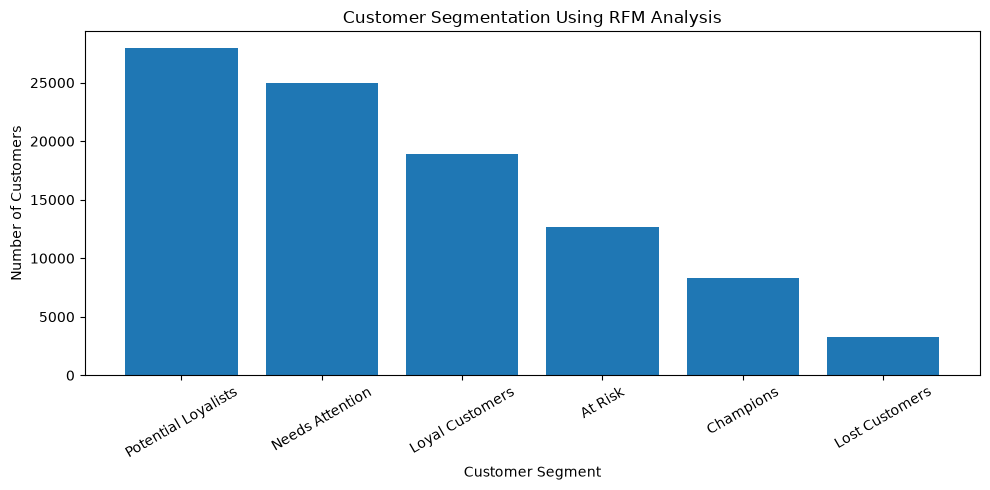

In [39]:
plt.figure(figsize=(10, 5))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Customers"]
)

plt.xticks(rotation=30)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segmentation Using RFM Analysis")
plt.tight_layout()
plt.show()

In [40]:
segment_revenue = (
    rfm.groupby("Segment")
    .agg(
        Customers=("customer_unique_id", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Revenue=("Monetary", "mean")
    )
    .reset_index()
)

segment_revenue["Revenue_%"] = (
    segment_revenue["Revenue"] /
    segment_revenue["Revenue"].sum() * 100
).round(2)

segment_revenue = segment_revenue.sort_values(
    "Revenue",
    ascending=False
)

segment_revenue

,Segment,Customers,Revenue,Avg_Revenue,Revenue_%
5,Potential Loyalists,27987,4015980.36,143.494492,29.55
3,Loyal Customers,18898,3933456.57,208.141421,28.94
1,Champions,8289,2463600.83,297.213274,18.13
4,Needs Attention,25009,2420497.82,96.785070,17.81
0,At Risk,12660,657276.08,51.917542,4.84
2,Lost Customers,3253,100832.04,30.996631,0.74


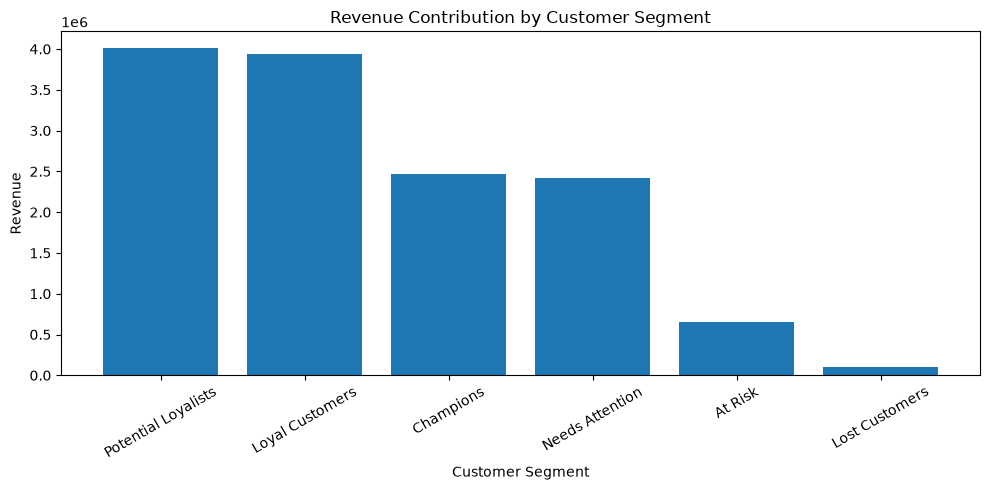

In [41]:
plt.figure(figsize=(10, 5))

plt.bar(
    segment_revenue["Segment"],
    segment_revenue["Revenue"]
)

plt.xticks(rotation=30)
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.title("Revenue Contribution by Customer Segment")
plt.tight_layout()
plt.show()

In [42]:
product_revenue = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

category_revenue = (
    product_revenue
    .groupby("product_category_name_english")["price"]
    .sum()
    .reset_index(name="revenue")
    .sort_values("revenue", ascending=False)
)

category_revenue.head(15)

,product_category_name_english,revenue
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


In [43]:
category_revenue["revenue_%"] = (
    category_revenue["revenue"] /
    category_revenue["revenue"].sum() * 100
).round(2)

category_revenue.head(15)

,product_category_name_english,revenue,revenue_%
43,health_beauty,1258681.34,9.39
70,watches_gifts,1205005.68,8.99
7,bed_bath_table,1036988.68,7.73
65,sports_leisure,988048.97,7.37
15,computers_accessories,911954.32,6.80
39,furniture_decor,729762.49,5.44
20,cool_stuff,635290.85,4.74
49,housewares,632248.66,4.72
5,auto,592720.11,4.42
42,garden_tools,485256.46,3.62


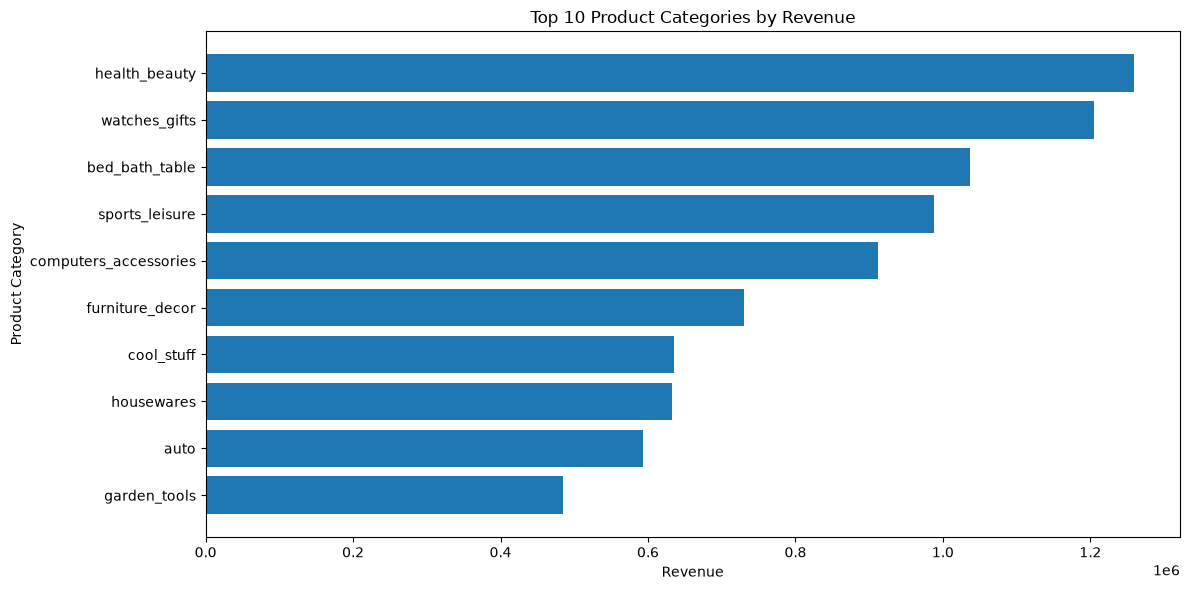

In [44]:
top_categories = category_revenue.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_categories["product_category_name_english"][::-1],
    top_categories["revenue"][::-1]
)

plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.title("Top 10 Product Categories by Revenue")

plt.tight_layout()
plt.show()

In [45]:
category_performance = (
    product_revenue
    .groupby("product_category_name_english")
    .agg(
        Units_Sold=("order_item_id", "count"),
        Revenue=("price", "sum"),
        Avg_Price=("price", "mean")
    )
    .reset_index()
)

category_performance["Revenue_%"] = (
    category_performance["Revenue"] /
    category_performance["Revenue"].sum() * 100
).round(2)

category_performance = category_performance.sort_values(
    "Revenue",
    ascending=False
)

category_performance.head(15)

,product_category_name_english,Units_Sold,Revenue,Avg_Price,Revenue_%
43,health_beauty,9670,1258681.34,130.163531,9.39
70,watches_gifts,5991,1205005.68,201.135984,8.99
7,bed_bath_table,11115,1036988.68,93.296327,7.73
65,sports_leisure,8641,988048.97,114.344285,7.37
15,computers_accessories,7827,911954.32,116.513903,6.80
39,furniture_decor,8334,729762.49,87.564494,5.44
20,cool_stuff,3796,635290.85,167.357969,4.74
49,housewares,6964,632248.66,90.788148,4.72
5,auto,4235,592720.11,139.957523,4.42
42,garden_tools,4347,485256.46,111.630196,3.62


In [46]:
category_performance.sort_values(
    "Units_Sold",
    ascending=False
).head(15)

,product_category_name_english,Units_Sold,Revenue,Avg_Price,Revenue_%
7,bed_bath_table,11115,1036988.68,93.296327,7.73
43,health_beauty,9670,1258681.34,130.163531,9.39
65,sports_leisure,8641,988048.97,114.344285,7.37
39,furniture_decor,8334,729762.49,87.564494,5.44
15,computers_accessories,7827,911954.32,116.513903,6.80
49,housewares,6964,632248.66,90.788148,4.72
70,watches_gifts,5991,1205005.68,201.135984,8.99
68,telephony,4545,323667.53,71.213978,2.41
42,garden_tools,4347,485256.46,111.630196,3.62
5,auto,4235,592720.11,139.957523,4.42


In [47]:
category_performance.sort_values(
    "Avg_Price",
    ascending=False
).head(15)

,product_category_name_english,Units_Sold,Revenue,Avg_Price,Revenue_%
14,computers,203,222963.13,1098.340542,1.66
64,small_appliances_home_oven_and_coffee,76,47445.71,624.285658,0.35
45,home_appliances_2,238,113317.74,476.124958,0.85
0,agro_industry_and_commerce,212,72530.47,342.124858,0.54
56,musical_instruments,680,191498.88,281.616000,1.43
63,small_appliances,679,190648.58,280.778468,1.42
34,fixed_telephony,264,59583.00,225.693182,0.44
19,construction_tools_safety,194,40544.52,208.992371,0.30
70,watches_gifts,5991,1205005.68,201.135984,8.99
1,air_conditioning,297,55024.96,185.269226,0.41


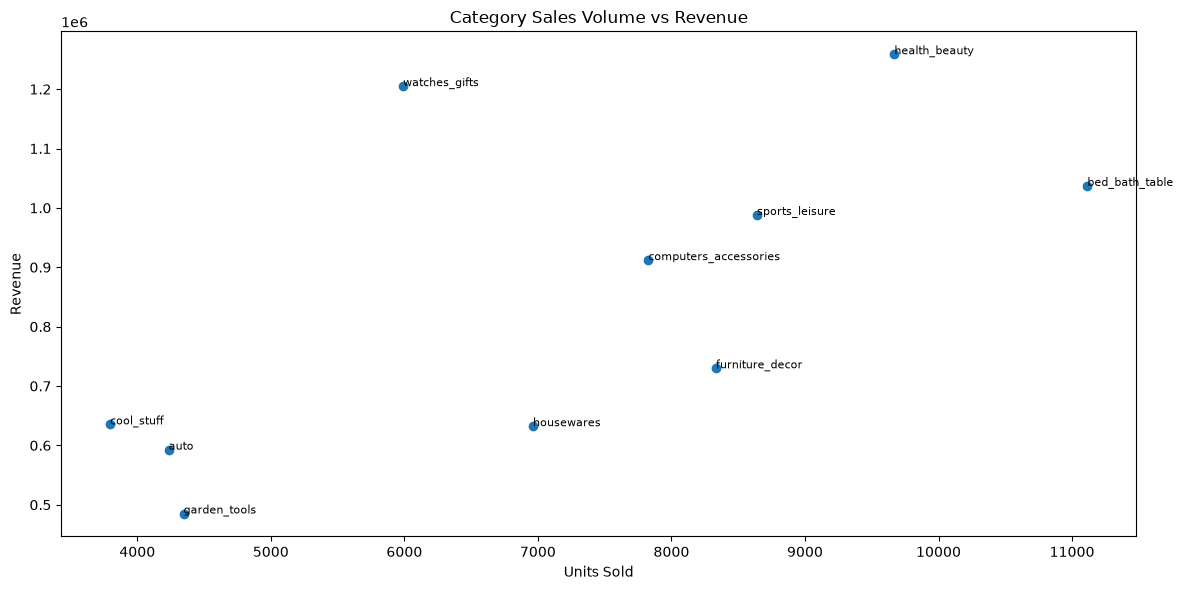

In [48]:
top10 = category_performance.head(10)

plt.figure(figsize=(12, 6))

plt.scatter(
    top10["Units_Sold"],
    top10["Revenue"]
)

for _, row in top10.iterrows():
    plt.annotate(
        row["product_category_name_english"],
        (row["Units_Sold"], row["Revenue"]),
        fontsize=8
    )

plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.title("Category Sales Volume vs Revenue")

plt.tight_layout()
plt.show()

In [49]:
category_performance.head(15)

,product_category_name_english,Units_Sold,Revenue,Avg_Price,Revenue_%
43,health_beauty,9670,1258681.34,130.163531,9.39
70,watches_gifts,5991,1205005.68,201.135984,8.99
7,bed_bath_table,11115,1036988.68,93.296327,7.73
65,sports_leisure,8641,988048.97,114.344285,7.37
15,computers_accessories,7827,911954.32,116.513903,6.80
39,furniture_decor,8334,729762.49,87.564494,5.44
20,cool_stuff,3796,635290.85,167.357969,4.74
49,housewares,6964,632248.66,90.788148,4.72
5,auto,4235,592720.11,139.957523,4.42
42,garden_tools,4347,485256.46,111.630196,3.62


In [54]:
# Step 19 — Reviews by Product Category

# Reviews → Order Items
review_products = (
    reviews
    .merge(
        order_items[["order_id", "product_id"]],
        on="order_id",
        how="left"
    )
)

# Order Items → Products
review_products = (
    review_products
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
)

# Products → English category names
review_products = (
    review_products
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

# Calculate review statistics by category
category_reviews = (
    review_products
    .groupby("product_category_name_english")
    .agg(
        Avg_Review_Score=("review_score", "mean"),
        Reviews=("review_id", "count")
    )
    .reset_index()
)

# Combine with our sales analysis
category_analysis = category_performance.merge(
    category_reviews,
    on="product_category_name_english",
    how="left"
)

# Categories with at least 100 reviews
high_review_categories = (
    category_analysis[
        category_analysis["Reviews"] >= 100
    ]
    .sort_values(
        "Avg_Review_Score",
        ascending=False
    )
)

high_review_categories.head(10)

,product_category_name_english,Units_Sold,Revenue,Avg_Price,Revenue_%,Avg_Review_Score,Reviews
35,books_general_interest,553,46856.88,84.732152,0.35,4.446266,549
48,books_technical,267,19096.06,71.520824,0.14,4.368421,266
50,food_drink,278,15179.48,54.602446,0.11,4.315412,279
24,luggage_accessories,1092,140429.98,128.598883,1.05,4.315257,1088
44,fashion_shoes,262,23562.77,89.934237,0.18,4.233716,261
40,food,510,29393.41,57.634137,0.22,4.218182,495
15,stationery,2517,230943.23,91.753369,1.72,4.193857,2507
17,pet_shop,1947,214315.41,110.074684,1.60,4.185147,1939
16,computers,203,222963.13,1098.340542,1.66,4.175000,200
27,home_appliances,771,80171.53,103.983826,0.60,4.172457,806


In [55]:
high_review_categories[
    [
        "product_category_name_english",
        "Revenue",
        "Units_Sold",
        "Avg_Price",
        "Avg_Review_Score",
        "Reviews"
    ]
].head(10)

,product_category_name_english,Revenue,Units_Sold,Avg_Price,Avg_Review_Score,Reviews
35,books_general_interest,46856.88,553,84.732152,4.446266,549
48,books_technical,19096.06,267,71.520824,4.368421,266
50,food_drink,15179.48,278,54.602446,4.315412,279
24,luggage_accessories,140429.98,1092,128.598883,4.315257,1088
44,fashion_shoes,23562.77,262,89.934237,4.233716,261
40,food,29393.41,510,57.634137,4.218182,495
15,stationery,230943.23,2517,91.753369,4.193857,2507
17,pet_shop,214315.41,1947,110.074684,4.185147,1939
16,computers,222963.13,203,1098.340542,4.175000,200
27,home_appliances,80171.53,771,103.983826,4.172457,806


In [56]:
# Categories with meaningful review volume
category_review_analysis = (
    category_analysis[
        category_analysis["Reviews"] >= 100
    ]
    .sort_values("Revenue", ascending=False)
)

category_review_analysis[
    [
        "product_category_name_english",
        "Revenue",
        "Units_Sold",
        "Avg_Price",
        "Avg_Review_Score",
        "Reviews"
    ]
].head(20)

,product_category_name_english,Revenue,Units_Sold,Avg_Price,Avg_Review_Score,Reviews
0,health_beauty,1258681.34,9670,130.163531,4.142768,9645
1,watches_gifts,1205005.68,5991,201.135984,4.019160,5950
2,bed_bath_table,1036988.68,11115,93.296327,3.895663,11137
3,sports_leisure,988048.97,8641,114.344285,4.107986,8640
4,computers_accessories,911954.32,7827,116.513903,3.930819,7849
5,furniture_decor,729762.49,8334,87.564494,3.903493,8331
6,cool_stuff,635290.85,3796,167.357969,4.146341,3772
7,housewares,632248.66,6964,90.788148,4.055019,6943
8,auto,592720.11,4235,139.957523,4.065512,4213
9,garden_tools,485256.46,4347,111.630196,4.042735,4329


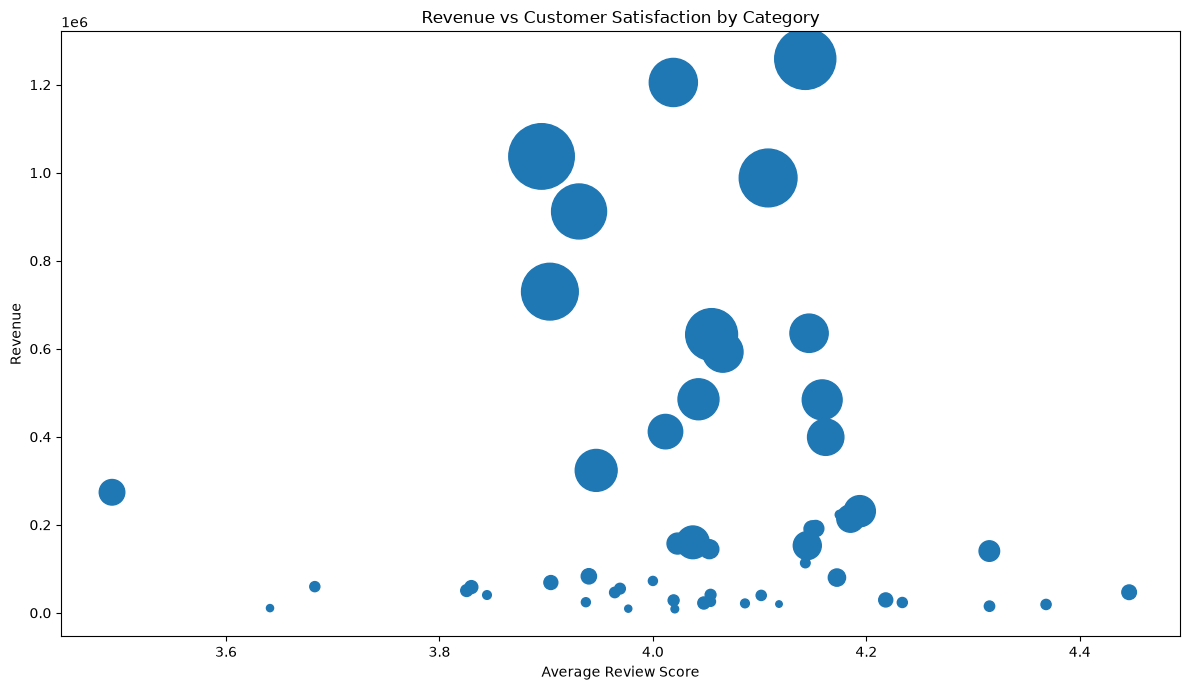

In [57]:
plt.figure(figsize=(12, 7))

plt.scatter(
    category_review_analysis["Avg_Review_Score"],
    category_review_analysis["Revenue"],
    s=category_review_analysis["Units_Sold"] / 5
)

plt.xlabel("Average Review Score")
plt.ylabel("Revenue")
plt.title("Revenue vs Customer Satisfaction by Category")
plt.tight_layout()
plt.show()

In [58]:
customer_states = (
    customers
    .groupby("customer_state")
    .size()
    .reset_index(name="Customers")
    .sort_values("Customers", ascending=False)
)

customer_states.head(15)

,customer_state,Customers
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [59]:
customer_states["Customer_%"] = (
    customer_states["Customers"] /
    customer_states["Customers"].sum() * 100
).round(2)

customer_states.head(15)

,customer_state,Customers,Customer_%
25,SP,41746,41.98
18,RJ,12852,12.92
10,MG,11635,11.70
22,RS,5466,5.50
17,PR,5045,5.07
23,SC,3637,3.66
4,BA,3380,3.40
6,DF,2140,2.15
7,ES,2033,2.04
8,GO,2020,2.03


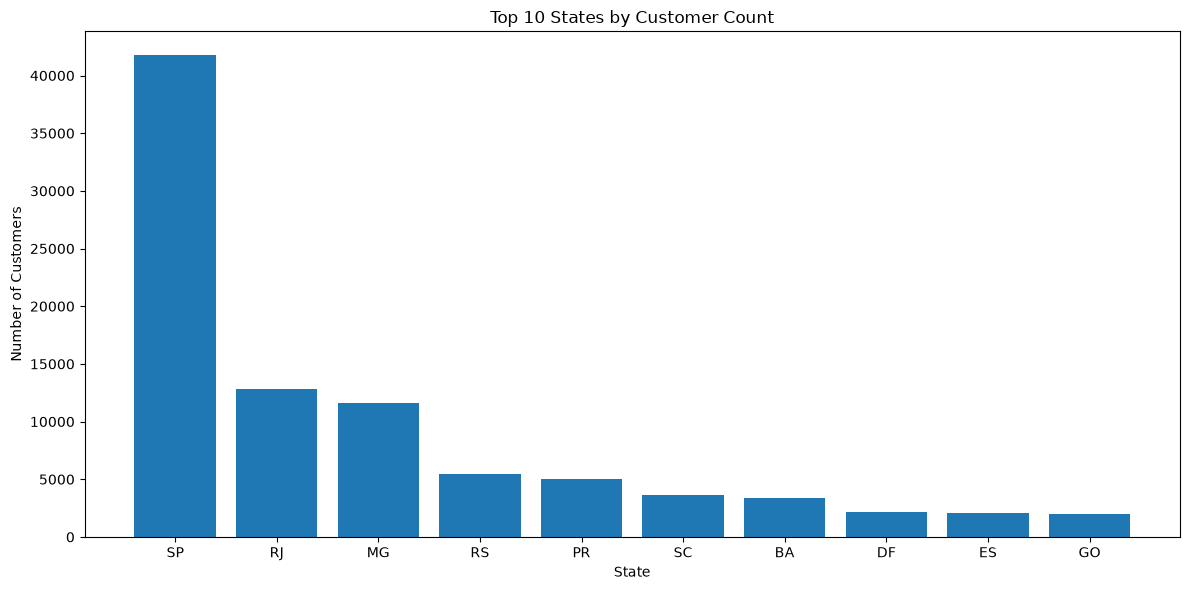

In [60]:
top_states = customer_states.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_states["customer_state"],
    top_states["Customers"]
)

plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.title("Top 10 States by Customer Count")

plt.tight_layout()
plt.show()

In [61]:
state_revenue = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        customers[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_state")["price"]
    .sum()
    .reset_index(name="Revenue")
    .sort_values("Revenue", ascending=False)
)

state_revenue["Revenue_%"] = (
    state_revenue["Revenue"] /
    state_revenue["Revenue"].sum() * 100
).round(2)

state_revenue.head(15)

,customer_state,Revenue,Revenue_%
25,SP,5202955.05,38.28
18,RJ,1824092.67,13.42
10,MG,1585308.03,11.66
22,RS,750304.02,5.52
17,PR,683083.76,5.03
23,SC,520553.34,3.83
4,BA,511349.99,3.76
6,DF,302603.94,2.23
8,GO,294591.95,2.17
7,ES,275037.31,2.02


In [62]:
state_revenue.head(10)

,customer_state,Revenue,Revenue_%
25,SP,5202955.05,38.28
18,RJ,1824092.67,13.42
10,MG,1585308.03,11.66
22,RS,750304.02,5.52
17,PR,683083.76,5.03
23,SC,520553.34,3.83
4,BA,511349.99,3.76
6,DF,302603.94,2.23
8,GO,294591.95,2.17
7,ES,275037.31,2.02


In [63]:
state_customers = (
    customers
    .groupby("customer_state")
    .agg(
        Customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

state_analysis = state_revenue.merge(
    state_customers,
    on="customer_state",
    how="left"
)

state_analysis["Revenue_per_Customer"] = (
    state_analysis["Revenue"] /
    state_analysis["Customers"]
).round(2)

state_analysis.sort_values(
    "Revenue_per_Customer",
    ascending=False
).head(15)

,customer_state,Revenue,Revenue_%,Customers,Revenue_per_Customer
16,PB,115268.08,0.85,519,222.10
24,AC,15982.95,0.12,77,207.57
25,AP,13474.30,0.10,67,201.11
19,AL,80314.81,0.59,401,200.29
22,RO,46140.64,0.34,240,192.25
12,PA,178947.81,1.32,949,188.56
21,TO,49621.74,0.37,273,181.76
17,PI,86914.08,0.64,482,180.32
13,MT,156453.53,1.15,876,178.60
18,RN,83034.98,0.61,474,175.18


In [64]:
state_analysis[
    state_analysis["Customers"] >= 500
].sort_values(
    "Revenue_per_Customer",
    ascending=False
).head(15)

,customer_state,Revenue,Revenue_%,Customers,Revenue_per_Customer
16,PB,115268.08,0.85,519,222.10
12,PA,178947.81,1.32,949,188.56
13,MT,156453.53,1.15,876,178.60
11,CE,227254.71,1.67,1313,173.08
15,MS,116812.64,0.86,694,168.32
14,MA,119648.22,0.88,726,164.80
10,PE,262788.03,1.93,1609,163.32
6,BA,511349.99,3.76,3277,156.04
8,GO,294591.95,2.17,1952,150.92
5,SC,520553.34,3.83,3534,147.30


In [65]:
payment_methods = (
    payments
    .groupby("payment_type")
    .agg(
        Payments=("payment_value", "count"),
        Revenue=("payment_value", "sum"),
        Avg_Payment=("payment_value", "mean")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

payment_methods["Revenue_%"] = (
    payment_methods["Revenue"] /
    payment_methods["Revenue"].sum() * 100
).round(2)

payment_methods

,payment_type,Payments,Revenue,Avg_Payment,Revenue_%
1,credit_card,76795,12542084.19,163.319021,78.34
0,boleto,19784,2869361.27,145.034435,17.92
4,voucher,5775,379436.87,65.703354,2.37
2,debit_card,1529,217989.79,142.570170,1.36
3,not_defined,3,0.00,0.000000,0.00


In [66]:
installments = (
    payments
    .groupby("payment_installments")
    .agg(
        Payments=("payment_value", "count"),
        Revenue=("payment_value", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

installments.head(15)

,payment_installments,Payments,Revenue
1,1,52546,5907233.36
10,10,5328,2211577.34
2,2,12413,1579283.03
3,3,10461,1491103.80
8,8,4268,1313423.34
4,4,7098,1163907.61
5,5,5239,961174.30
6,6,3920,822611.81
7,7,1626,305157.39
9,9,644,131015.92


In [67]:
order_payment = (
    payments
    .groupby("order_id")
    .agg(
        Payment_Value=("payment_value", "sum"),
        Payment_Type=("payment_type", "first"),
        Installments=("payment_installments", "max")
    )
    .reset_index()
)

payment_order_analysis = (
    order_payment
    .groupby("Payment_Type")
    .agg(
        Orders=("order_id", "count"),
        Total_Value=("Payment_Value", "sum"),
        Avg_Order_Value=("Payment_Value", "mean")
    )
    .reset_index()
    .sort_values("Total_Value", ascending=False)
)

payment_order_analysis

,Payment_Type,Orders,Total_Value,Avg_Order_Value
1,credit_card,75387,12561997.58,166.633472
0,boleto,19784,2869361.27,145.034435
4,voucher,2739,359573.48,131.279109
2,debit_card,1527,217939.79,142.724158
3,not_defined,3,0.00,0.000000


In [68]:
delivery_analysis = orders[
    orders["order_delivered_customer_date"].notna()
].copy()

delivery_analysis["delivery_delay_days"] = (
    delivery_analysis["order_delivered_customer_date"]
    - delivery_analysis["order_estimated_delivery_date"]
).dt.days

delivery_analysis.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,-8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,-6
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,-18
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,-13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,-10


In [69]:
total_delivered = len(delivery_analysis)

late_orders = (
    delivery_analysis["delivery_delay_days"] > 0
).sum()

on_time_orders = (
    delivery_analysis["delivery_delay_days"] <= 0
).sum()

late_delivery_rate = late_orders / total_delivered * 100

print("Delivered Orders:", total_delivered)
print("Late Orders:", late_orders)
print("On-Time Orders:", on_time_orders)
print("Late Delivery Rate:", round(late_delivery_rate, 2), "%")


Delivered Orders: 96476
Late Orders: 6535
On-Time Orders: 89941
Late Delivery Rate: 6.77 %


In [70]:
delivery_reviews = (
    delivery_analysis[
        ["order_id", "delivery_delay_days"]
    ]
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

delivery_reviews["delivery_status"] = np.where(
    delivery_reviews["delivery_delay_days"] > 0,
    "Late",
    "On Time"
)

delivery_reviews.head()

,order_id,delivery_delay_days,review_score,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,-8,4,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,-6,4,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,-18,5,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,-13,5,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,-10,5,On Time


In [71]:
delivery_rating = (
    delivery_reviews
    .groupby("delivery_status")
    .agg(
        Orders=("order_id", "count"),
        Avg_Review_Score=("review_score", "mean")
    )
    .reset_index()
)

delivery_rating

,delivery_status,Orders,Avg_Review_Score
0,Late,6410,2.271139
1,On Time,89949,4.289842


In [72]:
rating_by_delivery = pd.crosstab(
    delivery_reviews["delivery_status"],
    delivery_reviews["review_score"],
    normalize="index"
) * 100

rating_by_delivery.round(2)

review_score,1,2,3,4,5
delivery_status,,,,,
Late,53.73,8.67,10.89,10.17,16.54
On Time,6.63,2.65,8.08,20.38,62.26


In [73]:
late_order_revenue = (
    delivery_analysis[
        delivery_analysis["delivery_delay_days"] > 0
    ]
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="left"
    )
    .groupby("order_id")["price"]
    .sum()
)

on_time_order_revenue = (
    delivery_analysis[
        delivery_analysis["delivery_delay_days"] <= 0
    ]
    .merge(
        order_items[["order_id", "price"]],
        on="order_id",
        how="left"
    )
    .groupby("order_id")["price"]
    .sum()
)

print("Late Delivery Revenue:", round(late_order_revenue.sum(), 2))
print("On-Time Delivery Revenue:", round(on_time_order_revenue.sum(), 2))

Late Delivery Revenue: 985954.33
On-Time Delivery Revenue: 12234940.78


In [74]:
total_delivery_revenue = (
    late_order_revenue.sum() +
    on_time_order_revenue.sum()
)

late_revenue_share = (
    late_order_revenue.sum() /
    total_delivery_revenue * 100
)

print(
    "Revenue Associated With Late Deliveries:",
    round(late_revenue_share, 2),
    "%"
)

Revenue Associated With Late Deliveries: 7.46 %


In [75]:
category_delivery = (
    delivery_analysis[
        ["order_id", "delivery_delay_days"]
    ]
    .merge(
        order_items[["order_id", "product_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

category_delivery_summary = (
    category_delivery
    .groupby("product_category_name_english")
    .agg(
        Orders=("order_id", "nunique"),
        Avg_Delay_Days=("delivery_delay_days", "mean"),
        Late_Orders=("delivery_delay_days", lambda x: (x > 0).sum())
    )
    .reset_index()
)

category_delivery_summary["Late_Rate_%"] = (
    category_delivery_summary["Late_Orders"] /
    category_delivery_summary["Orders"] * 100
).round(2)

category_delivery_summary = (
    category_delivery_summary
    .sort_values("Late_Rate_%", ascending=False)
)

category_delivery_summary.head(20)

,product_category_name_english,Orders,Avg_Delay_Days,Late_Orders,Late_Rate_%
46,home_comfort_2,24,-8.433333,4,16.67
41,furniture_mattress_and_upholstery,37,-7.162162,5,13.51
4,audio,348,-10.149171,42,12.07
12,christmas_supplies,125,-12.053333,15,12.00
57,office_furniture,1254,-11.845923,133,10.61
33,fashion_underwear_beach,117,-10.929134,12,10.26
47,home_confort,392,-9.811189,40,10.20
39,furniture_decor,6307,-12.399510,574,9.10
18,construction_tools_lights,242,-11.222591,22,9.09
40,furniture_living_room,414,-11.800000,35,8.45


In [76]:
category_delivery_summary[
    category_delivery_summary["Orders"] >= 100
].head(20)

,product_category_name_english,Orders,Avg_Delay_Days,Late_Orders,Late_Rate_%
4,audio,348,-10.149171,42,12.07
12,christmas_supplies,125,-12.053333,15,12.00
57,office_furniture,1254,-11.845923,133,10.61
33,fashion_underwear_beach,117,-10.929134,12,10.26
47,home_confort,392,-9.811189,40,10.20
39,furniture_decor,6307,-12.399510,574,9.10
18,construction_tools_lights,242,-11.222591,22,9.09
40,furniture_living_room,414,-11.800000,35,8.45
7,bed_bath_table,9272,-11.656167,770,8.30
43,health_beauty,8649,-11.970107,717,8.29


In [77]:
late_orders_detail = delivery_analysis[
    delivery_analysis["delivery_delay_days"] > 0
].copy()

late_delay_summary = {
    "Late Orders": len(late_orders_detail),
    "Average Days Late": late_orders_detail["delivery_delay_days"].mean(),
    "Median Days Late": late_orders_detail["delivery_delay_days"].median(),
    "Maximum Days Late": late_orders_detail["delivery_delay_days"].max()
}

late_delay_summary

{'Late Orders': 6535,
 'Average Days Late': np.float64(10.6203519510329),
 'Median Days Late': np.float64(7.0),
 'Maximum Days Late': np.int64(188)}

In [78]:
late_orders_detail["delay_bucket"] = pd.cut(
    late_orders_detail["delivery_delay_days"],
    bins=[0, 3, 7, 14, 30, np.inf],
    labels=[
        "1-3 days",
        "4-7 days",
        "8-14 days",
        "15-30 days",
        "30+ days"
    ]
)

delay_distribution = (
    late_orders_detail
    .groupby("delay_bucket", observed=True)
    .size()
    .reset_index(name="Orders")
)

delay_distribution["Percentage"] = (
    delay_distribution["Orders"] /
    delay_distribution["Orders"].sum() * 100
).round(2)

delay_distribution

,delay_bucket,Orders,Percentage
0,1-3 days,1870,28.62
1,4-7 days,1802,27.57
2,8-14 days,1479,22.63
3,15-30 days,1039,15.90
4,30+ days,345,5.28


In [79]:
seller_performance = (
    order_items
    .merge(
        orders[["order_id", "order_status"]],
        on="order_id",
        how="left"
    )
    .merge(
        sellers[["seller_id", "seller_state"]],
        on="seller_id",
        how="left"
    )
    .groupby("seller_id")
    .agg(
        Orders=("order_id", "nunique"),
        Units_Sold=("order_item_id", "count"),
        Revenue=("price", "sum"),
        Avg_Item_Price=("price", "mean")
    )
    .reset_index()
)

seller_performance["Revenue_per_Order"] = (
    seller_performance["Revenue"] /
    seller_performance["Orders"]
).round(2)

seller_performance = seller_performance.sort_values(
    "Revenue",
    ascending=False
)

seller_performance.head(20)

,seller_id,Orders,Units_Sold,Revenue,Avg_Item_Price,Revenue_per_Order
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,198.505735,202.71
1013,53243585a1d6dc2643021fd1853d8905,358,410,222776.05,543.356220,622.28
881,4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92,100.892260,111.00
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03,331.129744,331.70
1535,7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,137.774113,191.37
1560,7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87,518.917265,525.09
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57,103.311779,121.95
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,121.046567,122.19
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,97.316912,151.88
1824,955fee9216a65b617aa5c0531780ce60,1287,1499,135171.70,90.174583,105.03


In [80]:
seller_delivery = (
    order_items[["order_id", "seller_id"]]
    .merge(
        orders[
            [
                "order_id",
                "order_delivered_customer_date",
                "order_estimated_delivery_date"
            ]
        ],
        on="order_id",
        how="left"
    )
)

seller_delivery = seller_delivery[
    seller_delivery["order_delivered_customer_date"].notna()
].copy()

seller_delivery["delivery_delay_days"] = (
    seller_delivery["order_delivered_customer_date"]
    - seller_delivery["order_estimated_delivery_date"]
).dt.days

seller_delivery_summary = (
    seller_delivery
    .groupby("seller_id")
    .agg(
        Orders=("order_id", "nunique"),
        Avg_Delay_Days=("delivery_delay_days", "mean"),
        Late_Orders=("delivery_delay_days", lambda x: (x > 0).sum())
    )
    .reset_index()
)

seller_delivery_summary["Late_Rate_%"] = (
    seller_delivery_summary["Late_Orders"] /
    seller_delivery_summary["Orders"] * 100
).round(2)

seller_delivery_summary = seller_delivery_summary[
    seller_delivery_summary["Orders"] >= 50
].sort_values(
    "Late_Rate_%",
    ascending=False
)

seller_delivery_summary.head(20)

,seller_id,Orders,Avg_Delay_Days,Late_Orders,Late_Rate_%
1000,54965bbe3e4f07ae045b90b0b8541f52,73,-2.395062,26,35.62
480,2a261b5b644fa05f4f2700eb93544f2c,51,-9.109756,16,31.37
2171,bbad7e518d7af88a0897397ffdca1979,68,-7.023810,19,27.94
1141,6039e27294dc75811c0d8a39069f52c0,63,-7.094595,16,25.40
2211,beadbee30901a7f61d031b6b686095ad,64,-9.661765,15,23.44
1928,a49928bcdf77c55c6d6e05e09a9b4ca5,96,-4.586538,22,22.92
513,2c9e548be18521d1c43cde1c582c6de8,124,-6.923977,28,22.58
1336,712e6ed8aa4aa1fa65dab41fed5737e4,77,-9.811765,17,22.08
160,0d85bbda9889ce1f7e63778d24f346eb,51,-10.120690,11,21.57
203,11bfa66332777660bd0640ee84d47006,76,-8.823529,16,21.05


In [81]:
seller_business_risk = (
    seller_performance[
        ["seller_id", "Orders", "Revenue"]
    ]
    .merge(
        seller_delivery_summary[
            ["seller_id", "Late_Rate_%"]
        ],
        on="seller_id",
        how="inner"
    )
)

seller_business_risk = seller_business_risk[
    seller_business_risk["Orders"] >= 100
].copy()

seller_business_risk = seller_business_risk.sort_values(
    ["Late_Rate_%", "Revenue"],
    ascending=[False, False]
)

seller_business_risk.head(20)

,seller_id,Orders,Revenue,Late_Rate_%
330,2c9e548be18521d1c43cde1c582c6de8,126,6109.44,22.58
62,06a2c3af7b3aee5d69171b0e14f0ee87,392,36408.95,20.05
75,88460e8ebdecbfecb5f9601833981930,248,31546.55,19.92
121,cd68562d3f44870c08922d380acae552,125,18569.70,18.85
290,e5a3438891c0bfdb9394643f95273d8e,224,7738.35,18.06
175,1ca7077d890b907f89be8c954a02686a,115,13341.57,17.59
40,8160255418d5aaa7dbdc9f4c64ebda44,385,47017.69,16.84
101,897060da8b9a21f655304d50fd935913,317,23023.92,15.13
361,b2479f944e1b90cf8a5de1bbfde284d6,103,4752.51,14.85
182,431af27f296bc6519d890aa5a05fdb11,117,13109.50,14.66


In [82]:
seller_risk = seller_business_risk.copy()

# Normalize metrics to 0-100
seller_risk["Revenue_Score"] = (
    seller_risk["Revenue"] /
    seller_risk["Revenue"].max() * 100
)

seller_risk["Volume_Score"] = (
    seller_risk["Orders"] /
    seller_risk["Orders"].max() * 100
)

seller_risk["Late_Score"] = (
    seller_risk["Late_Rate_%"] /
    seller_risk["Late_Rate_%"].max() * 100
)

# Weighted business risk
seller_risk["Risk_Score"] = (
    seller_risk["Revenue_Score"] * 0.4 +
    seller_risk["Volume_Score"] * 0.3 +
    seller_risk["Late_Score"] * 0.3
).round(2)

seller_risk = seller_risk.sort_values(
    "Risk_Score",
    ascending=False
)

seller_risk.head(20)

,seller_id,Orders,Revenue,Late_Rate_%,Revenue_Score,Volume_Score,Late_Score,Risk_Score
2,4a3ca9315b744ce9f8e9374361493884,1806,200472.92,10.67,87.362454,97.411003,47.254207,78.34
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63,10.77,100.000000,61.057174,47.697077,72.63
4,7c67e1448b00f6e969d365cea6b010ab,982,187923.89,12.33,81.893815,52.966559,54.605846,65.03
6,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57,7.55,69.828184,70.873786,33.436670,59.22
11,6560211a19b47992c3666cc44a7e94c0,1854,123304.83,5.61,53.734003,100.000000,24.844996,58.95
15,1f50f920176fa81dab994f9023523100,1404,106939.21,10.72,46.602163,75.728155,47.475642,55.60
3,fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03,9.17,84.559989,31.553398,40.611160,55.47
9,955fee9216a65b617aa5c0531780ce60,1287,135171.70,7.53,58.905369,69.417476,33.348096,54.39
8,1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55,10.44,60.559967,49.352751,46.235607,52.90
16,cc419e0650a3c5ba77189a1882b7556a,1706,104288.42,5.33,45.446997,92.017260,23.604960,52.87


In [83]:
seller_risk_plot = seller_business_risk[
    seller_business_risk["Orders"] >= 100
].copy()

seller_risk_plot[[
    "seller_id",
    "Orders",
    "Revenue",
    "Late_Rate_%"
]].sort_values(
    "Revenue",
    ascending=False
).head(20)

,seller_id,Orders,Revenue,Late_Rate_%
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63,10.77
1,53243585a1d6dc2643021fd1853d8905,358,222776.05,3.45
2,4a3ca9315b744ce9f8e9374361493884,1806,200472.92,10.67
3,fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03,9.17
4,7c67e1448b00f6e969d365cea6b010ab,982,187923.89,12.33
5,7e93a43ef30c4f03f38b393420bc753a,336,176431.87,4.70
6,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57,7.55
7,7a67c85e85bb2ce8582c35f2203ad736,1160,141745.53,5.24
8,1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55,10.44
9,955fee9216a65b617aa5c0531780ce60,1287,135171.70,7.53


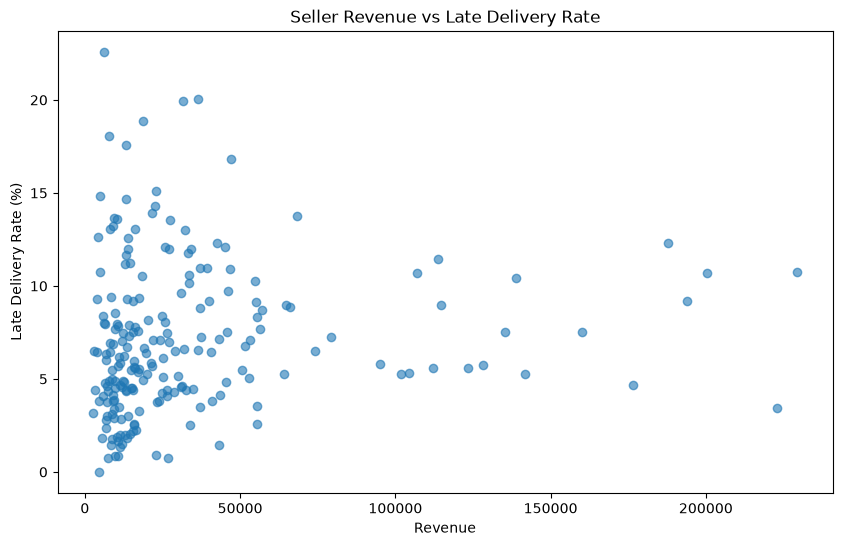

In [84]:
plt.figure(figsize=(10, 6))

plt.scatter(
    seller_risk_plot["Revenue"],
    seller_risk_plot["Late_Rate_%"],
    alpha=0.6
)

plt.xlabel("Revenue")
plt.ylabel("Late Delivery Rate (%)")
plt.title("Seller Revenue vs Late Delivery Rate")

plt.show()

In [85]:
customer_churn = rfm.copy()

customer_churn["Churn_Risk"] = np.where(
    (customer_churn["Frequency"] == 1) &
    (customer_churn["Recency"] > 180),
    "High Risk",
    np.where(
        customer_churn["Recency"] > 365,
        "At Risk",
        "Active"
    )
)

churn_summary = (
    customer_churn
    .groupby("Churn_Risk")
    .agg(
        Customers=("customer_unique_id", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Revenue=("Monetary", "mean")
    )
    .reset_index()
)

churn_summary["Customer_%"] = (
    churn_summary["Customers"] /
    churn_summary["Customers"].sum() * 100
).round(2)

churn_summary

,Churn_Risk,Customers,Revenue,Avg_Revenue,Customer_%
0,Active,29246,4372633.17,149.512178,30.43
1,At Risk,754,193454.57,256.571048,0.78
2,High Risk,66096,9025555.96,136.552226,68.78


In [86]:
high_value_churn = (
    customer_churn[
        customer_churn["Churn_Risk"].isin(
            ["High Risk", "At Risk"]
        )
    ]
    .sort_values(
        "Monetary",
        ascending=False
    )
)

high_value_churn[
    [
        "customer_unique_id",
        "Recency",
        "Frequency",
        "Monetary",
        "RFM_score",
        "Segment",
        "Churn_Risk"
    ]
].head(20)

,customer_unique_id,Recency,Frequency,Monetary,RFM_score,Segment,Churn_Risk
3826,0a0a92112bd4c708ca5fde585afaa872,383,1,13440.00,8,Needs Attention,High Risk
81962,da122df9eeddfedc1dc1f5349a1a690c,564,2,7388.00,11,Loyal Customers,At Risk
82808,dc4802a71eae9be1dd28f5d788ceb526,611,1,6735.00,11,Loyal Customers,High Risk
95806,ff4159b92c40ebe40454e3e6a7c35ed6,510,1,6499.00,11,Loyal Customers,High Risk
24121,4007669dec559734d6f53e029e360987,327,1,5934.60,9,Potential Loyalists,High Risk
89688,eebb5dda148d3893cdaf5b5ca3040ccb,546,1,4690.00,11,Loyal Customers,High Risk
93998,fa562ef24d41361e476e748681810e1e,202,1,4099.99,14,Champions,High Risk
2032,055ec572ac7f3c7bdd04a183830ebe59,455,2,3999.98,11,Loyal Customers,At Risk
426,011875f0176909c5cf0b14a9138bb691,577,1,3999.90,7,Needs Attention,High Risk
89420,edf81e1f3070b9dac83ec83dacdbb9bc,546,1,3999.00,11,Loyal Customers,High Risk


In [87]:
customer_priority = customer_churn.copy()

# Normalize monetary value
customer_priority["Value_Score"] = (
    customer_priority["Monetary"] /
    customer_priority["Monetary"].max() * 100
)

# Normalize recency
customer_priority["Recency_Risk"] = (
    customer_priority["Recency"] /
    customer_priority["Recency"].max() * 100
)

# Give additional weight to customers who purchased more than once
customer_priority["Frequency_Score"] = (
    customer_priority["Frequency"] /
    customer_priority["Frequency"].max() * 100
)

customer_priority["Priority_Score"] = (
    customer_priority["Value_Score"] * 0.5 +
    customer_priority["Recency_Risk"] * 0.3 +
    customer_priority["Frequency_Score"] * 0.2
).round(2)

priority_customers = (
    customer_priority[
        customer_priority["Churn_Risk"].isin(
            ["High Risk", "At Risk"]
        )
    ]
    .sort_values(
        "Priority_Score",
        ascending=False
    )
)

priority_customers[
    [
        "customer_unique_id",
        "Recency",
        "Frequency",
        "Monetary",
        "Churn_Risk",
        "Priority_Score"
    ]
].head(20)

,customer_unique_id,Recency,Frequency,Monetary,Churn_Risk,Priority_Score
3826,0a0a92112bd4c708ca5fde585afaa872,383,1,13440.00,High Risk,66.06
81962,da122df9eeddfedc1dc1f5349a1a690c,564,2,7388.00,At Risk,51.76
82808,dc4802a71eae9be1dd28f5d788ceb526,611,1,6735.00,High Risk,49.98
95806,ff4159b92c40ebe40454e3e6a7c35ed6,510,1,6499.00,High Risk,45.17
35581,5e713be0853d8986528d7869a0811d2b,619,1,3980.00,High Risk,40.04
89688,eebb5dda148d3893cdaf5b5ca3040ccb,546,1,4690.00,High Risk,39.84
35067,5d09b0d82126457e2a8ebfb9c9a1ffc4,614,1,3699.99,High Risk,38.80
426,011875f0176909c5cf0b14a9138bb691,577,1,3999.90,High Risk,38.48
1320,03796b63235e0e0a299084988c662c7e,602,1,3549.00,High Risk,37.77
89420,edf81e1f3070b9dac83ec83dacdbb9bc,546,1,3999.00,High Risk,37.27


In [88]:
segment_summary = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("customer_unique_id", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .reset_index()
)

segment_summary["Customer_%"] = (
    segment_summary["Customers"] /
    segment_summary["Customers"].sum() * 100
).round(2)

segment_summary["Revenue_%"] = (
    segment_summary["Revenue"] /
    segment_summary["Revenue"].sum() * 100
).round(2)

segment_summary.sort_values(
    "Revenue",
    ascending=False
)

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_%,Revenue_%
5,Potential Loyalists,27987,4015980.36,265.543252,1.015078,143.494492,29.12,29.55
3,Loyal Customers,18898,3933456.57,208.466875,1.061118,208.141421,19.67,28.94
1,Champions,8289,2463600.83,141.853661,1.201351,297.213274,8.63,18.13
4,Needs Attention,25009,2420497.82,334.238994,1.003959,96.785070,26.03,17.81
0,At Risk,12660,657276.08,407.334439,1.000000,51.917542,13.17,4.84
2,Lost Customers,3253,100832.04,487.925300,1.000000,30.996631,3.39,0.74


In [89]:
segment_chart = segment_summary[
    [
        "Segment",
        "Customer_%",
        "Revenue_%"
    ]
].copy()

segment_chart


,Segment,Customer_%,Revenue_%
0,At Risk,13.17,4.84
1,Champions,8.63,18.13
2,Lost Customers,3.39,0.74
3,Loyal Customers,19.67,28.94
4,Needs Attention,26.03,17.81
5,Potential Loyalists,29.12,29.55


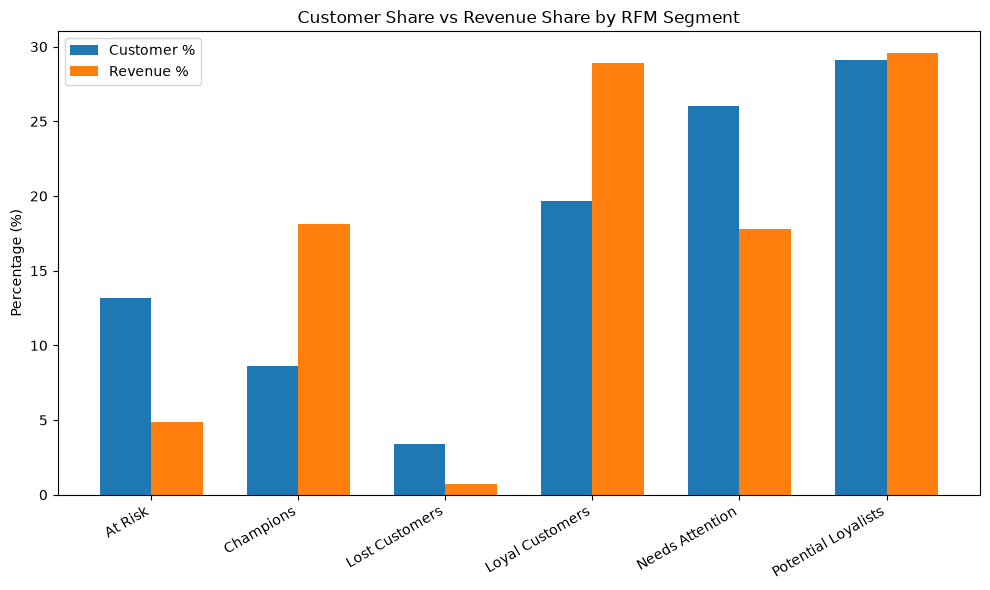

In [90]:
plt.figure(figsize=(10, 6))

x = np.arange(len(segment_chart))
width = 0.35

plt.bar(
    x - width/2,
    segment_chart["Customer_%"],
    width,
    label="Customer %"
)

plt.bar(
    x + width/2,
    segment_chart["Revenue_%"],
    width,
    label="Revenue %"
)

plt.xticks(
    x,
    segment_chart["Segment"],
    rotation=30,
    ha="right"
)

plt.ylabel("Percentage (%)")
plt.title("Customer Share vs Revenue Share by RFM Segment")
plt.legend()

plt.tight_layout()
plt.show()

In [91]:
product_performance = (
    order_items
    .merge(
        products[[
            "product_id",
            "product_category_name"
        ]],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
    .groupby(
        ["product_id", "product_category_name_english"]
    )
    .agg(
        Units_Sold=("order_item_id", "count"),
        Revenue=("price", "sum"),
        Avg_Price=("price", "mean")
    )
    .reset_index()
)

product_performance = product_performance.sort_values(
    "Revenue",
    ascending=False
)

product_performance.head(20)

,product_id,product_category_name_english,Units_Sold,Revenue,Avg_Price
23641,bb50f2e236e5eea0100680137654686c,health_beauty,195,63885.00,327.615385
13808,6cdd53843498f92890544667809f1595,health_beauty,156,54730.20,350.834615
27102,d6160fb7873f184099d9bc95e30376af,computers,35,48899.34,1397.124000
26533,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,343,47214.51,137.651633
19387,99a4788cb24856965c36a24e339b6058,bed_bath_table,488,43025.56,88.167131
7902,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,274,41082.60,149.936496
4901,25c38557cf793876c5abdd5931f922db,baby,38,38907.32,1023.876842
12125,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,63,37733.90,598.950794
10662,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,323,37683.42,116.666935
21716,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,527,37608.90,71.364137


In [92]:
total_product_revenue = product_performance["Revenue"].sum()

concentration = []

for n in [10, 20, 50, 100]:
    revenue = product_performance.head(n)["Revenue"].sum()
    share = revenue / total_product_revenue * 100

    concentration.append({
        "Top_N_Products": n,
        "Revenue": revenue,
        "Revenue_Share_%": share
    })

concentration_df = pd.DataFrame(concentration)

concentration_df

,Top_N_Products,Revenue,Revenue_Share_%
0,10,450770.75,3.362306
1,20,730342.15,5.447634
2,50,1248351.22,9.311472
3,100,1817826.30,13.559196


In [93]:
product_performance[
    ["product_id",
     "product_category_name_english",
     "Units_Sold",
     "Revenue",
     "Avg_Price"]
].sort_values(
    "Units_Sold",
    ascending=False
).head(20)

,product_id,product_category_name_english,Units_Sold,Revenue,Avg_Price
21716,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,527,37608.90,71.364137
19387,99a4788cb24856965c36a24e339b6058,bed_bath_table,488,43025.56,88.167131
8453,422879e10f46682990de24d770e7f83d,garden_tools,484,26577.22,54.911612
7228,389d119b48cf3043d311335e499d9c6b,garden_tools,392,21440.59,54.695383
6947,368c6c730842d78016ad823897a372db,garden_tools,388,21056.80,54.270103
10635,53759a2ecddad2bb87a079a1f1519f73,garden_tools,373,20387.20,54.657373
26533,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,343,47214.51,137.651633
10662,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,323,37683.42,116.666935
2741,154e7e31ebfa092203795c972e5804a6,health_beauty,281,6325.19,22.509573
7902,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,274,41082.60,149.936496


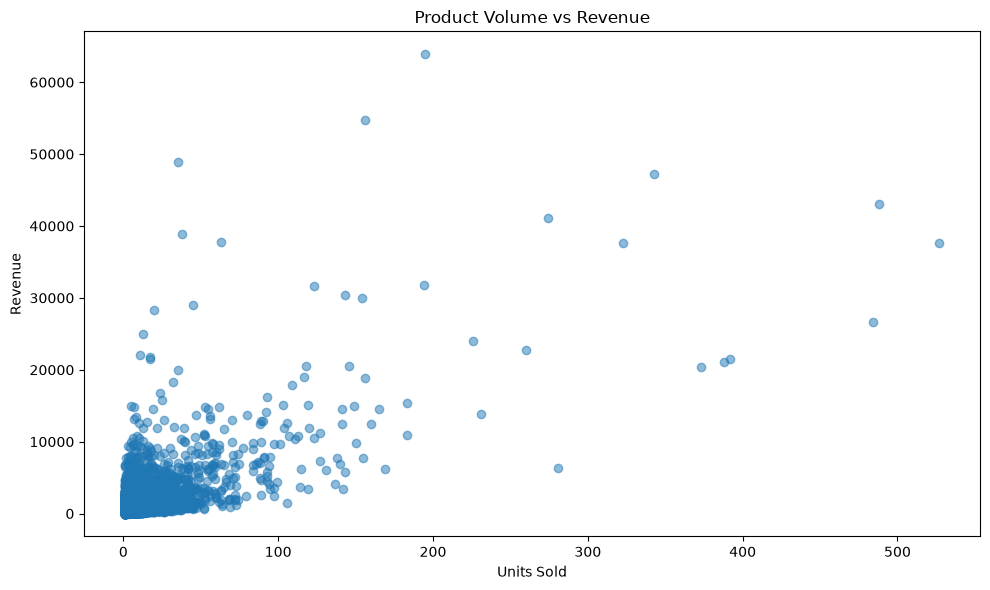

In [94]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_performance["Units_Sold"],
    product_performance["Revenue"],
    alpha=0.5
)

plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.title("Product Volume vs Revenue")

plt.tight_layout()
plt.show()

In [95]:
product_score = product_performance.copy()

product_score["Revenue_Score"] = (
    product_score["Revenue"] /
    product_score["Revenue"].max() * 100
)

product_score["Volume_Score"] = (
    product_score["Units_Sold"] /
    product_score["Units_Sold"].max() * 100
)

product_score["Performance_Score"] = (
    product_score["Revenue_Score"] * 0.5 +
    product_score["Volume_Score"] * 0.5
).round(2)

top_products = product_score.sort_values(
    "Performance_Score",
    ascending=False
)

top_products[
    [
        "product_id",
        "product_category_name_english",
        "Units_Sold",
        "Revenue",
        "Avg_Price",
        "Performance_Score"
    ]
].head(20)

,product_id,product_category_name_english,Units_Sold,Revenue,Avg_Price,Performance_Score
19387,99a4788cb24856965c36a24e339b6058,bed_bath_table,488,43025.56,88.167131,79.97
21716,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,527,37608.90,71.364137,79.43
26533,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,343,47214.51,137.651633,69.50
23641,bb50f2e236e5eea0100680137654686c,health_beauty,195,63885.00,327.615385,68.50
8453,422879e10f46682990de24d770e7f83d,garden_tools,484,26577.22,54.911612,66.72
10662,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,323,37683.42,116.666935,60.14
7902,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,274,41082.60,149.936496,58.15
13808,6cdd53843498f92890544667809f1595,health_beauty,156,54730.20,350.834615,57.64
7228,389d119b48cf3043d311335e499d9c6b,garden_tools,392,21440.59,54.695383,53.97
6947,368c6c730842d78016ad823897a372db,garden_tools,388,21056.80,54.270103,53.29


In [96]:
category_matrix = (
    product_performance
    .groupby("product_category_name_english")
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        Avg_Price=("Avg_Price", "mean")
    )
    .reset_index()
)

category_matrix = category_matrix.sort_values(
    "Revenue",
    ascending=False
)

category_matrix.head(20)

,product_category_name_english,Units_Sold,Revenue,Avg_Price
43,health_beauty,9670,1258681.34,146.776607
70,watches_gifts,5991,1205005.68,335.905481
7,bed_bath_table,11115,1036988.68,107.463381
65,sports_leisure,8641,988048.97,135.441691
15,computers_accessories,7827,911954.32,156.028732
39,furniture_decor,8334,729762.49,103.233978
20,cool_stuff,3796,635290.85,214.696681
49,housewares,6964,632248.66,98.561100
5,auto,4235,592720.11,152.576804
42,garden_tools,4347,485256.46,222.614460


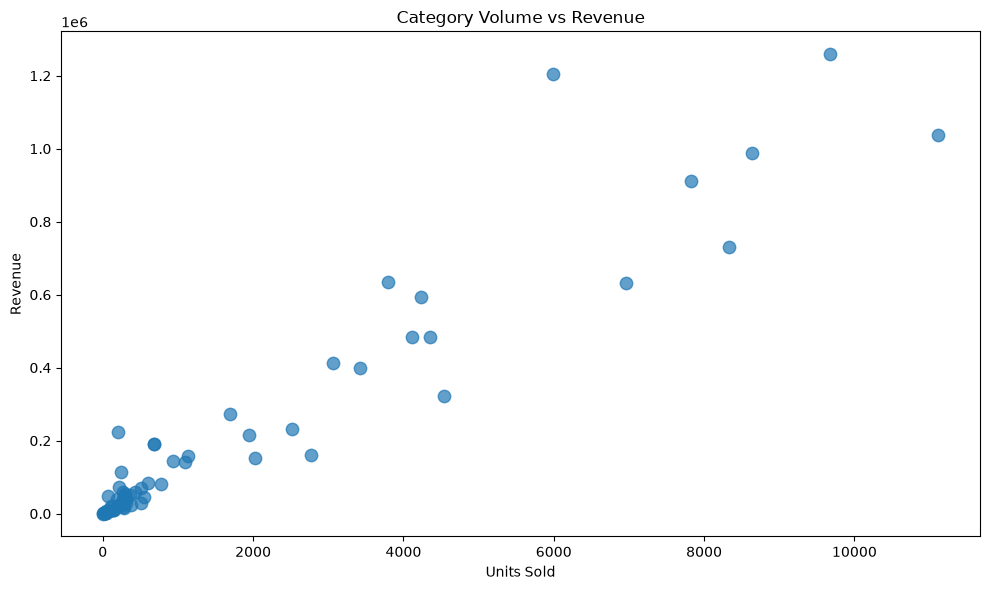

In [97]:
plt.figure(figsize=(10, 6))

plt.scatter(
    category_matrix["Units_Sold"],
    category_matrix["Revenue"],
    s=80,
    alpha=0.7
)

plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.title("Category Volume vs Revenue")

plt.tight_layout()
plt.show()

In [98]:
category_matrix["Revenue_%"] = (
    category_matrix["Revenue"] /
    category_matrix["Revenue"].sum() * 100
).round(2)

category_matrix["Units_%"] = (
    category_matrix["Units_Sold"] /
    category_matrix["Units_Sold"].sum() * 100
).round(2)

category_matrix["Revenue_vs_Units"] = (
    category_matrix["Revenue_%"] -
    category_matrix["Units_%"]
).round(2)

category_matrix.sort_values(
    "Revenue_vs_Units",
    ascending=False
).head(20)

,product_category_name_english,Units_Sold,Revenue,Avg_Price,Revenue_%,Units_%,Revenue_vs_Units
70,watches_gifts,5991,1205005.68,335.905481,8.99,5.40,3.59
14,computers,203,222963.13,1368.067042,1.66,0.18,1.48
20,cool_stuff,3796,635290.85,214.696681,4.74,3.42,1.32
56,musical_instruments,680,191498.88,335.303545,1.43,0.61,0.82
63,small_appliances,679,190648.58,349.437088,1.42,0.61,0.81
43,health_beauty,9670,1258681.34,146.776607,9.39,8.71,0.68
45,home_appliances_2,238,113317.74,508.155697,0.85,0.21,0.64
5,auto,4235,592720.11,152.576804,4.42,3.81,0.61
57,office_furniture,1691,273960.70,209.481686,2.04,1.52,0.52
0,agro_industry_and_commerce,212,72530.47,438.692969,0.54,0.19,0.35


In [99]:
category_matrix[
    [
        "product_category_name_english",
        "Units_Sold",
        "Revenue",
        "Revenue_%",
        "Units_%",
        "Revenue_vs_Units"
    ]
].sort_values(
    "Revenue_vs_Units",
    ascending=True
).head(20)

,product_category_name_english,Units_Sold,Revenue,Revenue_%,Units_%,Revenue_vs_Units
7,bed_bath_table,11115,1036988.68,7.73,10.01,-2.28
39,furniture_decor,8334,729762.49,5.44,7.51,-2.07
68,telephony,4545,323667.53,2.41,4.09,-1.68
49,housewares,6964,632248.66,4.72,6.27,-1.55
26,electronics,2767,160246.74,1.20,2.49,-1.29
28,fashion_bags_accessories,2031,152823.54,1.14,1.83,-0.69
66,stationery,2517,230943.23,1.72,2.27,-0.55
65,sports_leisure,8641,988048.97,7.37,7.78,-0.41
42,garden_tools,4347,485256.46,3.62,3.92,-0.30
15,computers_accessories,7827,911954.32,6.80,7.05,-0.25


In [100]:
category_risk = (
    category_analysis
    .merge(
        category_delivery_summary[
            [
                "product_category_name_english",
                "Late_Rate_%"
            ]
        ],
        on="product_category_name_english",
        how="left"
    )
)

category_risk = category_risk[
    category_risk["Reviews"] >= 100
].copy()

category_risk[
    [
        "product_category_name_english",
        "Revenue",
        "Units_Sold",
        "Avg_Review_Score",
        "Reviews",
        "Late_Rate_%"
    ]
].sort_values(
    ["Late_Rate_%", "Avg_Review_Score"],
    ascending=[False, True]
).head(20)

,product_category_name_english,Revenue,Units_Sold,Avg_Review_Score,Reviews,Late_Rate_%
33,audio,50688.50,364,3.825485,361,12.07
53,christmas_supplies,8800.82,153,4.020548,146,12.00
14,office_furniture,273960.70,1691,3.493183,1687,10.61
52,fashion_underwear_beach,9541.55,131,3.976923,130,10.26
31,home_confort,58572.04,434,3.829885,435,10.20
5,furniture_decor,729762.49,8334,3.903493,8331,9.10
37,construction_tools_lights,41080.00,304,4.054054,296,9.09
29,furniture_living_room,68916.56,503,3.904382,502,8.45
2,bed_bath_table,1036988.68,11115,3.895663,11137,8.30
0,health_beauty,1258681.34,9670,4.142768,9645,8.29


In [102]:
category_opportunity = category_risk.copy()

category_opportunity["Revenue_Score"] = (
    category_opportunity["Revenue"] /
    category_opportunity["Revenue"].max() * 100
)

category_opportunity["Late_Score"] = (
    category_opportunity["Late_Rate_%"] /
    category_opportunity["Late_Rate_%"].max() * 100
)

category_opportunity["Review_Risk_Score"] = (
    (5 - category_opportunity["Avg_Review_Score"]) /
    (5 - category_opportunity["Avg_Review_Score"].min()) * 100
)

category_opportunity["Opportunity_Score"] = (
    category_opportunity["Revenue_Score"] * 0.4 +
    category_opportunity["Late_Score"] * 0.3 +
    category_opportunity["Review_Risk_Score"] * 0.3
).round(2)

category_opportunity = category_opportunity.sort_values(
    "Opportunity_Score",
    ascending=False
)

category_opportunity[
    [
        "product_category_name_english",
        "Revenue",
        "Avg_Review_Score",
        "Late_Rate_%",
        "Opportunity_Score"
    ]
].head(20)

,product_category_name_english,Revenue,Avg_Review_Score,Late_Rate_%,Opportunity_Score
0,health_beauty,1258681.34,4.142768,8.29,77.67
1,watches_gifts,1205005.68,4.019160,7.68,76.91
2,bed_bath_table,1036988.68,3.895663,8.30,75.57
4,computers_accessories,911954.32,3.930819,7.60,69.16
5,furniture_decor,729762.49,3.903493,9.10,67.64
3,sports_leisure,988048.97,4.107986,7.07,66.73
14,office_furniture,273960.70,3.493183,10.61,65.08
8,auto,592720.11,4.065512,7.64,56.43
33,audio,50688.50,3.825485,12.07,54.99
9,garden_tools,485256.46,4.042735,8.12,54.66


In [103]:
geo_opportunity = state_analysis.copy()

geo_opportunity["Revenue_Score"] = (
    geo_opportunity["Revenue"] /
    geo_opportunity["Revenue"].max() * 100
)

geo_opportunity["Customer_Score"] = (
    geo_opportunity["Customers"] /
    geo_opportunity["Customers"].max() * 100
)

geo_opportunity["Revenue_Per_Customer_Score"] = (
    geo_opportunity["Revenue_per_Customer"] /
    geo_opportunity["Revenue_per_Customer"].max() * 100
)

geo_opportunity["Opportunity_Score"] = (
    geo_opportunity["Revenue_Score"] * 0.4 +
    geo_opportunity["Customer_Score"] * 0.3 +
    geo_opportunity["Revenue_Per_Customer_Score"] * 0.3
).round(2)

geo_opportunity = geo_opportunity.sort_values(
    "Opportunity_Score",
    ascending=False
)

geo_opportunity[
    [
        "customer_state",
        "Revenue",
        "Customers",
        "Revenue_per_Customer",
        "Opportunity_Score"
    ]
].head(15)

,customer_state,Revenue,Customers,Revenue_per_Customer,Opportunity_Score
0,SP,5202955.05,40302,129.10,87.44
1,RJ,1824092.67,12384,147.29,43.14
2,MG,1585308.03,11259,140.80,39.59
16,PB,115268.08,519,222.10,31.27
3,RS,750304.02,5277,142.18,28.90
24,AC,15982.95,77,207.57,28.22
19,AL,80314.81,401,200.29,27.97
4,PR,683083.76,4882,139.92,27.79
12,PA,178947.81,949,188.56,27.55
6,BA,511349.99,3277,156.04,27.45


In [104]:
kpis = {
    "Total Orders": orders["order_id"].nunique(),
    "Total Customers": customers["customer_unique_id"].nunique(),
    "Total Revenue": order_items["price"].sum(),
    "Average Order Value": order_items["price"].sum() / orders["order_id"].nunique(),
    "Repeat Customer Rate %": repeat_rate,
    "On-Time Delivery %": 93.23,
    "Average Review Score": reviews["review_score"].mean(),
    "Credit Card Revenue %": 78.34,
    "Top State": state_revenue.iloc[0]["customer_state"],
    "Top Category": category_performance.iloc[0]["product_category_name_english"]
}

kpi_table = pd.DataFrame(
    kpis.items(),
    columns=["KPI", "Value"]
)

kpi_table

,KPI,Value
0,Total Orders,99441
1,Total Customers,96096
2,Total Revenue,13591643.7
3,Average Order Value,136.680481
4,Repeat Customer Rate %,3.118756
5,On-Time Delivery %,93.23
6,Average Review Score,4.086421
7,Credit Card Revenue %,78.34
8,Top State,SP
9,Top Category,health_beauty
